## DAMATH DYNA-Q

In [1]:
# Imports
import torch
import copy
import random
import numpy as np
from collections import defaultdict
from operator import pos
import matplotlib.pyplot as plt


In [2]:
# Auto-select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Class Environment of Damath

### Damath Board and Operations

In [3]:
import torch # Assuming torch is available based on your original code

class DamathEnvironment:
    def __init__(self, device='cpu'): # Changed default to 'cpu' for wider compatibility
        self.device = device
        self.board = torch.zeros((8, 8), dtype=torch.int32, device=self.device)
        self.board_size = 8
        self.EMPTY_SQUARE = 999.0 # Must be a float since initial_board is float32

        # Fixed Damath board template (as you requested not to change)
        self.initial_board_template = [
            [2, "#", -5, "#", 8, "#", -11, "#"],
            ["#", -7, "#", 10, "#", -3, "#", "0"],
            [4, "#", -1, "#", 9, "#", -6, "#"],
            ["#", "#", "#", "#", "#", "#", "#", "#"],
            ["#", "#", "#", "#", "#", "#", "#", "#"],
            ["#", -9, "#", 6, "#", -1, "#", 4],
            ["0", "#", -3, "#", 10, "#", -7, "#"],
            ["#", -11, "#", 8, "#", -5, "#", 2]
        ]

        # Convert to tensor, replacing "#" with a special empty value
        board_values = []
        for row in self.initial_board_template:
            tensor_row = []
            for cell in row:
                if cell == "#":
                    tensor_row.append(self.EMPTY_SQUARE)
                elif cell == "0":  # Handle string "0" (actual piece)
                    tensor_row.append(0.0) # Ensure it's a float
                else:
                    tensor_row.append(float(cell))
            board_values.append(tensor_row)

        self.initial_board = torch.tensor(board_values, dtype=torch.float32, device=device)

        # Operations board (as you requested not to change)
        self.operations_board = [
            ["+", "#", "÷", "#", "-", "#", "×", "#"],
            ["#", "×", "#", "+", "#", "÷", "#", "-"],
            ["-", "#", "+", "#", "÷", "#", "×", "#"],
            ["#", "÷", "#", "-", "#", "×", "#", "+"],
            ["×", "#", "÷", "#", "-", "#", "+", "#"],
            ["#", "+", "#", "÷", "#", "-", "#", "×"],
            ["÷", "#", "×", "#", "+", "#", "-", "#"],
            ["#", "-", "#", "×", "#", "+", "#", "÷"],
        ]
        
        # Game state tracking for draw condition
        self.consecutive_non_capture_moves = 0
        self.max_non_capture_moves = 20 # Limit steps before forced draw check

        self.reset()
        
    # --- Utility Methods for Damath Logic ---
    
    def _apply_operation(self, piece_value, captured_value, op_symbol):
        """Calculates the result of the Damath operation."""
        # Use absolute values for the calculation, as is standard in Damath
        piece_abs = abs(piece_value)
        captured_abs = abs(captured_value)

        # Division: Integer division (floor) and handle division by zero
        if op_symbol == "÷":
            if captured_abs == 0:
                # Based on common Damath rules, division by 0 is usually 0
                return 0.0
            else:
                return float(piece_abs // captured_abs)
        # Subtraction: Result must be non-negative
        elif op_symbol == "-":
            return max(0.0, piece_abs - captured_abs)
        # Addition
        elif op_symbol == "+":
            return piece_abs + captured_abs
        # Multiplication
        elif op_symbol == "×":
            return piece_abs * captured_abs
        else:
            return 0.0 # Should not happen if op_symbol is one of the four

    def _is_valid_coord(self, r, c):
        """Checks if coordinates are within board bounds."""
        return 0 <= r < self.board_size and 0 <= c < self.board_size

    # --- Core Game Logic Methods ---

    def get_valid_moves(self, pos):
        """Generate all valid moves (including multi-step Dama moves/jumps) for a piece at position `pos`."""
        r, c = pos
        piece = self.board[r, c].item()
        
        if piece == self.EMPTY_SQUARE or self.operations_board[r][c] == "#":
            return []
        
        moves = []
        is_king = abs(piece) > 12
        
        # Directions: Player 1 (positive) moves up (-1, *), Player 2 (negative) moves down (+1, *)
        # Kings move in all 4 diagonal directions
        directions = []
        if is_king:
            directions = [(-1, -1), (-1, 1), (1, -1), (1, 1)]
        elif piece > 0: # Player 1 (Positive)
            directions = [(-1, -1), (-1, 1)]
        elif piece < 0: # Player 2 (Negative)
            directions = [(1, -1), (1, 1)]

        for dr, dc in directions:
            # 1. Simple Move
            nr, nc = r + dr, c + dc
            if self._is_valid_coord(nr, nc) and self.board[nr, nc].item() == self.EMPTY_SQUARE:
                op_symbol = self.operations_board[nr][nc]
                if op_symbol != "#": # Only move to operational squares
                    promoted = (piece > 0 and nr == 0 and not is_king) or \
                               (piece < 0 and nr == self.board_size - 1 and not is_king)
                    moves.append((nr, nc, op_symbol, [], promoted))

            # 2. Jump (Capture) - Regular piece (single step)
            jr, jc = r + 2 * dr, c + 2 * dc
            mid_r, mid_c = r + dr, c + dc
            
            if not is_king and \
               self._is_valid_coord(jr, jc) and \
               self._is_valid_coord(mid_r, mid_c) and \
               self.board[jr, jc].item() == self.EMPTY_SQUARE and \
               self.operations_board[jr][jc] != "#":
                
                captured_piece = self.board[mid_r, mid_c].item()
                # Check for opponent piece on mid square
                if captured_piece != self.EMPTY_SQUARE and captured_piece * piece < 0:
                    op_symbol = self.operations_board[jr][jc]
                    promoted = (piece > 0 and jr == 0) or (piece < 0 and jr == self.board_size - 1)
                    moves.append((jr, jc, op_symbol, [(mid_r, mid_c)], promoted))

            # 3. King (Dama) Jump (Capture) - Multiple steps (fly)
            if is_king:
                # Recursive search for all possible jump sequences for the king
                king_jumps = self._get_king_jumps(r, c, dr, dc, piece, initial_jump=True)
                moves.extend(king_jumps)

        # In case of multiple jumps (regular pieces), only the first jump is listed here.
        # However, Damath jump rules allow for a single jump to be chosen.
        # Multi-jump sequences are more complex, but we'll stick to single jumps for non-kings for simplicity,
        # focusing on king (dama) multi-step capture.
        
        # Filter for jumps if any are available for this piece
        jumps = [move for move in moves if move[3]] # move[3] is 'captured' list
        return jumps if jumps else moves
    
    def _get_king_jumps(self, r, c, dr, dc, piece, initial_jump=False):
        """
        Recursively finds all possible king jumps in a single direction.
        A Damath King/Dama captures an enemy piece at any distance and lands on an empty operation square immediately after the capture.
        """
        jumps = []
        captured_pos = None
        
        # Iterate until the edge of the board
        for i in range(1, self.board_size):
            pr, pc = r + i * dr, c + i * dc # Potential piece/empty square
            
            if not self._is_valid_coord(pr, pc):
                break
            
            current_square = self.board[pr, pc].item()
            
            if captured_pos is None:
                # Looking for a piece to capture
                if current_square != self.EMPTY_SQUARE and current_square * piece < 0:
                    captured_pos = (pr, pc)
                elif current_square != self.EMPTY_SQUARE and current_square * piece > 0:
                    # Blocked by own piece
                    break
                
            elif captured_pos is not None:
                # We have captured a piece, now look for an empty operation square to land on
                if current_square == self.EMPTY_SQUARE and self.operations_board[pr][pc] != "#":
                    op_symbol = self.operations_board[pr][pc]
                    # Kings are already promoted, so 'promoted' is always False for a king's move
                    
                    # Store the jump (from the original starting position to the landing square)
                    # The full action must be from the *original* piece position
                    # We return the end move for this step, and the main function will combine it.
                    jumps.append((pr, pc, op_symbol, [captured_pos], False))
                
                elif current_square != self.EMPTY_SQUARE:
                    # Landing square is blocked by another piece (own or opponent)
                    break
        
        return jumps

    def get_all_valid_actions(self):
        """Get all valid actions for current player, enforcing jump priority."""
        all_actions = []
        jumps_available = []

        for r in range(self.board_size):
            for c in range(self.board_size):
                piece = self.board[r, c].item()
                if piece == self.EMPTY_SQUARE:
                    continue
                
                # Check for current player's pieces (positive for P1, negative for P2)
                is_current_player_piece = (self.current_player > 0 and piece > 0) or \
                                          (self.current_player < 0 and piece < 0)
                
                if is_current_player_piece:
                    moves = self.get_valid_moves((r, c))
                    
                    for move in moves:
                        to_r, to_c, op_symbol, captured, promoted = move
                        action = ((r, c), (to_r, to_c), op_symbol, captured, promoted)
                        
                        if captured:
                            jumps_available.append(action)
                        else:
                            all_actions.append(action)

        # Enforce Jump Priority: If any jump is available, only return jumps
        return jumps_available if jumps_available else all_actions

    def step(self, action):
        """Apply an action to the board with PROPER Damath scoring."""
        self.done = False
        (from_pos, to_pos, op_symbol, captured, promoted) = action
        from_r, from_c = from_pos
        to_r, to_c = to_pos
        
        piece = self.board[from_r, from_c].item()
        
        # 1. Calculate Reward (Score)
        reward = 0.0
        is_capture = bool(captured)
        
        if is_capture:
            # Standard Damath Scoring: Result of the operation using the landing square's operator
            cr, cc = captured[0]
            captured_piece_value = self.board[cr, cc].item()
            
            # The score is the result of the operation on the absolute values
            reward = self._apply_operation(piece, captured_piece_value, op_symbol)
            
            # Reset non-capture move counter
            self.consecutive_non_capture_moves = 0
            
            # Remove captured pieces
            for (cr, cc) in captured:
                self.board[cr, cc] = self.EMPTY_SQUARE
        else:
            # Increment non-capture move counter
            self.consecutive_non_capture_moves += 1

        # 2. Move Piece
        self.board[from_r, from_c] = self.EMPTY_SQUARE
        self.board[to_r, to_c] = piece

        # 3. Promotion
        if promoted:
            # Promote to a King (Dama) by adding/subtracting 12.0
            new_value = abs(piece) + 12.0
            self.board[to_r, to_c] = new_value if piece > 0 else -new_value
            # Reward for promotion (usually not a score but a bonus in RL)
            # Keeping your original logic for promotion bonus
            reward += 2.0

        # 4. Update Score and Player
        self.scores[self.current_player] += reward
        self.current_player *= -1 # Switch player

        # 5. Check Game Over Conditions
        next_actions = self.get_all_valid_actions()

        # a) No more moves for the next player
        if not next_actions:
            self.done = True
        
        # b) Draw conditions based on limited steps/pieces
        elif self._check_draw_conditions():
            self.done = True
            
        # c) Draw condition based on consecutive non-capture moves
        elif self.consecutive_non_capture_moves >= self.max_non_capture_moves:
             self.done = True
             print(f"Game over by 20 consecutive non-capture moves rule.")

        # 6. Final Reward Adjustment (Game Over)
        if self.done:
            winner, final_scores = self.determine_winner()
            
            # Keeping your original logic for final reward adjustment
            if winner == -self.current_player: # The player who *just* moved is the winner
                reward += 10
            elif winner != 0:
                reward -= 5

        return self.board.clone(), reward, self.done

    def _check_draw_conditions(self):
        """Checks for specific Damath Draw rules."""
        player1_pieces, player2_pieces = 0, 0
        player1_kings, player2_kings = 0, 0
        
        for r in range(self.board_size):
            for c in range(self.board_size):
                piece_value = self.board[r, c].item()
                if piece_value == self.EMPTY_SQUARE:
                    continue
                
                is_king = abs(piece_value) > 12.0
                
                if piece_value > 0:
                    player1_pieces += 1
                    if is_king:
                        player1_kings += 1
                else:
                    player2_pieces += 1
                    if is_king:
                        player2_kings += 1

        # 1. One piece remains for each player
        if player1_pieces == 1 and player2_pieces == 1:
            return True

        # 2. The other player doesn't have valid moves (Already covered by self.done = True check)
        
        # 3. Two dama pieces remains for one player, then one dama piece to other player (and no piece can be eaten for the next move)
        # Assuming "then" implies current state.
        # This rule often includes a count limit (e.g., 5 non-capture moves for this configuration)
        # For simplicity, we implement the state check only.
        if (player1_kings == 2 and player2_kings == 1 and player1_pieces == 2 and player2_pieces == 1) or \
           (player1_kings == 1 and player2_kings == 2 and player1_pieces == 1 and player2_pieces == 2):
            
            # Check if *any* piece can be eaten. If not, it's a draw.
            # This check is complex to do accurately without an extended search,
            # but we can rely on the limited number of non-capture moves to cover this dynamic draw.
            # For a pure "piece count" draw, it's often combined with a move limit.
            
            # Simple interpretation: if only kings remain in this configuration, it's a draw if no jumps are available.
            current_actions = self.get_all_valid_actions()
            jumps = [action for action in current_actions if action[3]]
            if not jumps:
                # If no jumps are available with this piece configuration, declare a draw.
                return True

        return False

    def calculate_final_scores(self):
        """Calculate final scores by adding remaining pieces to current scores (Dama pieces * 2)."""
        final_scores = self.scores.copy()
        
        for r in range(self.board_size):
            for c in range(self.board_size):
                piece_value = self.board[r, c].item()
                if piece_value == self.EMPTY_SQUARE:
                    continue
                
                abs_value = abs(piece_value)
                is_king = abs_value > 12.0
                value = abs_value
                
                # King piece value is doubled (2x value for the final count)
                if is_king:
                    # Piece values 13, 14, ... (representing 1, 2, ...) are counted as 1, 2, ...
                    # The base value (1 to 12) is what's doubled.
                    base_value = abs_value - 12.0
                    value = base_value * 2.0
                
                if piece_value > 0:
                    final_scores[1] += value
                else:
                    final_scores[-1] += value

        return final_scores

    # --- Existing/Unmodified Methods for Completeness (omitted for brevity) ---
    def reset(self):
        """Reset the game to initial state."""
        self.board = self.initial_board.clone()
        self.current_player = 1  # Player 1 starts
        self.scores = {1: 0.0, -1: 0.0}  # track scores separately (use floats)
        self.consecutive_non_capture_moves = 0
        self.done = False
        return self._get_state()

    def _get_state(self):
        """Return current board state."""
        return self.board.clone()

    # The render_board method remains as is
    def render_board(self):
        """Pretty-print the Damath board with ops and pieces."""
        board_str = []
        for r in range(self.board_size):
            row_str = []
            for c in range(self.board_size):
                if self.operations_board[r][c] == "#":
                    row_str.append(" # ")
                    continue
                val = self.board[r, c].item()
                if val == self.EMPTY_SQUARE:
                    row_str.append(" . ")
                else:
                    # Adjusted formatting to show King (Dama) with a 'K' prefix
                    is_king = abs(val) > 12.0
                    display_val = int(abs(val)) if not is_king else int(abs(val) - 12)
                    prefix = "K" if is_king else ""
                    sign = "" if val >= 0 else "-"
                    row_str.append(f"{sign}{prefix}{display_val: <2}")
            board_str.append(" ".join(row_str))
        print("\n".join(board_str))
        print(f"Scores: P1={self.scores[1]:.1f}  P2={self.scores[-1]:.1f}")
        
    # The determine_winner method remains as is
    def determine_winner(self):
        """Determine the winner based on final scores."""
        final_scores = self.calculate_final_scores()

        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[-1] > final_scores[1]:
            winner = -1
        else:
            winner = 0
        return winner, final_scores
    
    # The parse_move method is now mostly redundant as get_valid_moves is the source of truth,
    # but kept for potential external move parsing.
    def parse_move(self, from_r, from_c, to_r, to_c):
        """Parse a move and return move details including captures and promotions (simplified)."""
        # This function is usually not needed when using get_all_valid_actions
        # but provides a best-guess action structure.
        
        # NOTE: This only checks for a single-step move/jump. It cannot fully validate a Dama/King move.
        
        op_symbol = None
        if self._is_valid_coord(to_r, to_c):
            op = self.operations_board[to_r][to_c]
            op_symbol = op if op != "#" else None

        captured = []
        dr, dc = to_r - from_r, to_c - from_c
        
        # Check for simple jump (2 steps)
        if abs(dr) == 2 and abs(dc) == 2:
            mid_r, mid_c = from_r + dr // 2, from_c + dc // 2
            if self._is_valid_coord(mid_r, mid_c):
                if self.board[mid_r, mid_c].item() != self.EMPTY_SQUARE:
                    captured.append((mid_r, mid_c)) # Only captures if a piece is there

        promoted = False
        piece = self.board[from_r, from_c].item()
        
        if piece is not None and piece != self.EMPTY_SQUARE:
            is_king = abs(piece) > 12.0
            if not is_king:
                # Promotion row check
                if (piece > 0 and to_r == 0) or (piece < 0 and to_r == self.board_size - 1):
                    promoted = True

        return (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted

## Damath Agent

In [4]:
import numpy as np
import random
import torch # Import if not already done in the environment
# import matplotlib.pyplot as plt # Assuming this is available in the global scope

class DynaQAgent:
    def __init__(self, planning_steps=30, alpha=0.05, gamma=0.9, epsilon=0.2):
        self.q_table = {}
        self.model = {}
        self.planning_steps = planning_steps
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon_start = epsilon
        self.epsilon_end = 0.01
        self.epsilon_decay = 0.995
        self.epsilon = epsilon
        
    def decay_epsilon(self):
        """Gradually reduce exploration as training progresses"""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)

    def _action_to_hashable(self, action):
        """Converts the complex action tuple to a hashable tuple."""
        if action is None:
            return None
        # Action is: ((from_r, from_c), (to_r, to_c), op_symbol, captured, promoted)
        (from_pos, to_pos, op_symbol, captured, promoted) = action
        captured_tuple = tuple(captured) if captured else ()
        # Ensure all components are hashable: tuples for positions/captured, string for op, bool for promoted
        return (from_pos, to_pos, op_symbol, captured_tuple, promoted)

    def _state_to_hashable(self, state_tensor):
        """Converts the board tensor state to a hashable tuple of integers."""
        # Convert tensor to a flat list of integers, then to a tuple.
        # It's crucial to cast to int/float and remove torch tensor properties.
        # We need to explicitly handle the float values (like 999.0) by rounding or casting.
        return tuple(int(x) if x == self.EMPTY_SQUARE or abs(x) >= 12 else round(x) for x in state_tensor.flatten().tolist())

    def choose_action(self, state_hash, valid_actions):
        if not valid_actions:
            return None
        
        if np.random.rand() < self.epsilon:
            # Exploration: Choose a random valid action
            return valid_actions[np.random.randint(len(valid_actions))]
        
        # Exploitation: Choose the best action based on Q-table
        hashable_actions = [self._action_to_hashable(a) for a in valid_actions]
        
        # Get Q-values for all valid (state, action) pairs. Default to 0.
        q_vals = [self.q_table.get((state_hash, ha), 0) for ha in hashable_actions]
        
        # Select the index of the action with the maximum Q-value
        best_action_index = int(np.argmax(q_vals))
        return valid_actions[best_action_index]

    def learn(self, state_hash, action, reward, next_state_hash, next_actions):
        """Update Q from real experience + planning steps."""
        ha = self._action_to_hashable(action)

        # --- 1. Q-learning update (real experience)
        old_q = self.q_table.get((state_hash, ha), 0)
        
        # Calculate max Q for the next state
        next_q = 0
        if next_actions:
            # CRITICAL FIX: Only check Q-values for the actual valid *next* actions (for the opposing player)
            hashable_next = [self._action_to_hashable(a) for a in next_actions]
            next_q = max([self.q_table.get((next_state_hash, h), 0) for h in hashable_next], default=0)
            
        new_q = old_q + self.alpha * (reward + self.gamma * next_q - old_q)
        self.q_table[(state_hash, ha)] = new_q

        # --- 2. Store in model
        # Store (reward, next_state) for the action taken from the current state.
        self.model[(state_hash, ha)] = (reward, next_state_hash)

        # --- 3. Planning (sample from model)
        if not self.model: # Avoid error if model is empty (first step)
            return

        for _ in range(self.planning_steps):
            # Sample (state, action) from model's keys
            (s, a), (r, s_next) = random.choice(list(self.model.items()))
            
            old_q = self.q_table.get((s, a), 0)

            # CRITICAL FIX: Estimate best next action value based ONLY on model-sampled next state (s_next)
            # Find all known hashable actions (h) for the next state (s_next) in the Q-table.
            # This is inefficient, but necessary for the Dyna-Q tabular approach.
            next_actions_in_q = [h for (state_key, h) in self.q_table.keys() if state_key == s_next]
            
            q_next = max([self.q_table.get((s_next, h), 0) for h in next_actions_in_q], default=0)

            new_q = old_q + self.alpha * (r + self.gamma * q_next - old_q)
            self.q_table[(s, a)] = new_q

## Training Loop

Starting Dyna-Q Training for 2000 episodes...
Episode 1/2000 - Reward: 210.00, Steps: 52, Epsilon: 0.199, Q-table size: 52
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Episode 101/2000 - Reward: 235.00, Steps: 42, Epsilon: 0.121, Q-table size: 1498
Game over by 20 consecutive non-capture moves rule.
Game over by 20 consecutive non-capture moves rule.
Game over by 20 

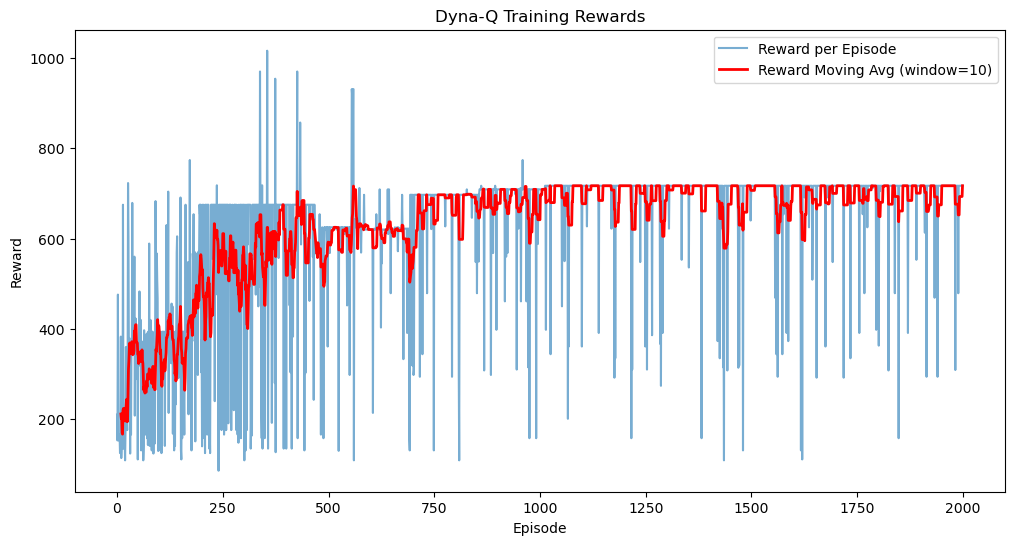

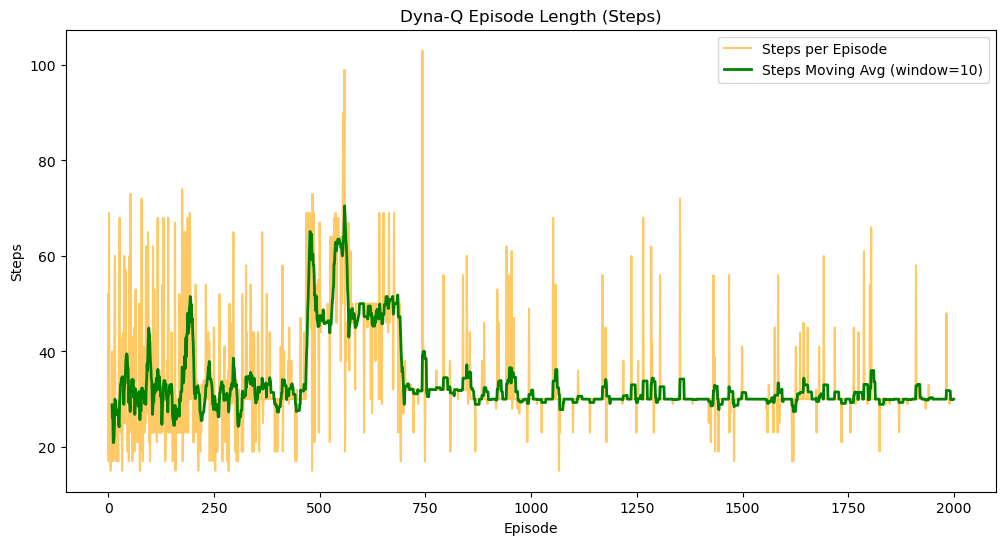

In [5]:
env = DamathEnvironment(device=device)
agent = DynaQAgent(planning_steps=50)
agent.EMPTY_SQUARE = env.EMPTY_SQUARE

rewards_per_episode = []
steps_per_episode = []

# Use the state hashing function from the agent for consistency
def get_state_hash(state_tensor):
    return agent._state_to_hashable(state_tensor)

rewards_per_episode = []
steps_per_episode = []

episodes = 2000 # Increased episodes for better learning
MAX_STEPS = 200 # Increased step limit as Damath games can be longer

print(f"Starting Dyna-Q Training for {episodes} episodes...")

for ep in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0
    steps = 0
    
    # CRITICAL FIX: Call decay_epsilon outside the loop or after a certain step count
    agent.decay_epsilon() 

    while not done and steps < MAX_STEPS:
        # Determine the current player's state representation
        current_state_hash = get_state_hash(state)
        
        # 1. Choose Action
        valid_actions = env.get_all_valid_actions()
        action = agent.choose_action(current_state_hash, valid_actions)
        
        if not action:
            # No valid actions for the current player (game over)
            done = True
            reward = 0
            next_state = state # Stays the same, but 'done' is true
            break

        # 2. Step Environment
        # env.step handles the current player's move, score, and switches player internally.
        next_state, reward, done = env.step(action)
        
        # The environment returns the 'next_state' and the game switches to the *other* player.
        next_state_hash = get_state_hash(next_state)

        total_reward += reward
        steps += 1
        
        # 3. Learn
        # Get the new player's (opponent's) valid actions to calculate Q_max(s', a')
        next_actions = env.get_all_valid_actions()
        
        # Agent learns from the transition: (current_state, action, reward, next_state, next_actions_for_opponent)
        agent.learn(current_state_hash, action, reward, next_state_hash, next_actions)
        
        # Prepare for the next loop iteration
        state = next_state
    
    # End of Episode Reporting
    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)
    
    if ep % 100 == 0 or ep == episodes - 1:
        print(f"Episode {ep+1}/{episodes} - Reward: {total_reward:.2f}, Steps: {steps}, Epsilon: {agent.epsilon:.3f}, Q-table size: {len(agent.q_table)}")


# --- Moving averages ---
window = 10
reward_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode="valid")
steps_avg = np.convolve(steps_per_episode, np.ones(window)/window, mode="valid")

# --- Plot Rewards ---
plt.figure(figsize=(12,6))
plt.plot(rewards_per_episode, label="Reward per Episode", alpha=0.6)
plt.plot(range(window-1, episodes), reward_avg, label=f"Reward Moving Avg (window={window})", color="red", linewidth=2)
plt.xlabel("Episode"); plt.ylabel("Reward")
plt.title("Dyna-Q Training Rewards")
plt.legend(); plt.show()

# --- Plot Steps ---
plt.figure(figsize=(12,6))
plt.plot(steps_per_episode, label="Steps per Episode", alpha=0.6, color="orange")
plt.plot(range(window-1, episodes), steps_avg, label=f"Steps Moving Avg (window={window})", color="green", linewidth=2)
plt.xlabel("Episode"); plt.ylabel("Steps")
plt.title("Dyna-Q Episode Length (Steps)")
plt.legend(); plt.show()

## Sample Play

In [ ]:
print("\n🎮 Sample Match with PROPER Damath Scoring:")
state = env.reset()
env.render_board()

done = False
step_count = 0

while not done and step_count < 30:
    step_count += 1
    current_player = env.current_player
    
    score_before = env.scores[current_player]
    valid_actions = env.get_all_valid_actions()
    action = agent.choose_action(str(state.tolist()), valid_actions)
    
    if not action:
        print(f"❌ Player {current_player} has no valid moves left!")
        break

    (from_r, from_c), (to_r, to_c), op_symbol, captured, promoted = action

    print(f"\nStep {step_count} | 🟢 Player {current_player} moves:")
    print(f"   ➡️ From ({from_r},{from_c}) → To ({to_r},{to_c})")
    
    piece_value = env.board[from_r, from_c].item()
    print(f"   🔸 Moving piece with value: {int(piece_value)}")
    
    if captured:
        captured_value = int(env.board[captured[0][0], captured[0][1]].item())
        print(f"   ⚔️ Captured piece at {captured[0]} with value {captured_value}")
        
        if op_symbol and op_symbol != "#":
            print(f"   🔢 Landing on OPERATION square: {op_symbol}")
            captured_abs = abs(captured_value)
            if op_symbol == "+":
                expected_score = abs(int(piece_value)) + captured_abs
            elif op_symbol == "-":
                expected_score = max(0, abs(int(piece_value)) - captured_abs)
            elif op_symbol == "×":
                expected_score = abs(int(piece_value)) * captured_abs
            elif op_symbol == "÷":
                expected_score = abs(int(piece_value)) // captured_abs if captured_abs != 0 else 0
            print(f"   📊 Damath Score: |{abs(int(piece_value))}| {op_symbol} |{abs(captured_value)}| = {expected_score}")
        else:
            print(f"   ⚪ Landing on neutral square (#) - No score from operation")
    else:
        print(f"   👟 Normal move (no capture)")
        print(f"   📝 No capture = No score (Damath rule)")

    state, reward, done = env.step(action)
    score_after = env.scores[current_player]  # Use current_player since we haven't switched yet
    score_gained = score_after - score_before
    
    if promoted:
        print("   👑 Piece promoted to DAMATH KING! (+2 bonus)")

    print(f"   🏆 Actual reward gained: {reward}")
    print(f"   📈 Score change: {score_before} → {score_after} (+{score_gained})")
    
    env.render_board()

# Game result
if done:
    print("\n✅ Game Over!")
    print(f"📊 Scores from Gameplay - P1: {env.scores[1]}, P2: {env.scores[-1]}")
    
    # Calculate final scores using the built-in method
    winner_player, final_scores = env.determine_winner()
    
    print(f"\n📊 FINAL Scores (including remaining pieces):")
    print(f"   Player 1: {final_scores[1]}")
    print(f"   Player 2: {final_scores[-1]}")
    
    if winner_player == 1:
        winner = "Player 1"
    elif winner_player == -1:
        winner = "Player 2"
    else:
        winner = "TIE"
    print(f"🎉 Winner: {winner}")
else:
    print(f"\n⏰ Game stopped after {step_count} steps (demo limit reached)")
    print(f"📊 Current Scores - P1: {env.scores[1]}, P2: {env.scores[-1]}")



🎮 Sample Match with PROPER Damath Scoring:
2   #  -5   #  8   #  -11  # 
 #  -7   #  10  #  -3   #  0 
4   #  -1   #  9   #  -6   # 
 #   .   #   .   #   .   #   . 
 .   #   .   #   .   #   .   # 
 #  -9   #  6   #  -1   #  4 
0   #  -3   #  10  #  -7   # 
 #  -11  #  8   #  -5   #  2 
Scores: P1=0.0  P2=0.0

Step 1 | 🟢 Player 1 moves:
   ➡️ From (6,4) → To (4,6)
   🔸 Moving piece with value: 10
   ⚔️ Captured piece at (5, 5) with value -1
   🔢 Landing on OPERATION square: +
   📊 Damath Score: |10| + |1| = 11
   🏆 Actual reward gained: 11.0
   📈 Score change: 0.0 → 11.0 (+11.0)
2   #  -5   #  8   #  -11  # 
 #  -7   #  10  #  -3   #  0 
4   #  -1   #  9   #  -6   # 
 #   .   #   .   #   .   #   . 
 .   #   .   #   .   #  10  # 
 #  -9   #  6   #   .   #  4 
0   #  -3   #   .   #  -7   # 
 #  -11  #  8   #  -5   #  2 
Scores: P1=11.0  P2=0.0

Step 2 | 🟢 Player -1 moves:
   ➡️ From (1,5) → To (3,3)
   🔸 Moving piece with value: -3
   ⚔️ Captured piece at (2, 4) with value 9
   🔢 Landing